##Імпорти

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import re
import string
import os
from wordcloud import WordCloud



In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from src.preprocessing import preprocess

## Завантаження даних

In [ ]:
df = pd.read_csv('../data/IMDB Dataset.csv.zip')

##EDA

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.shape

(50000, 2)

Бачимо, що в нашому датасеті 50000 рядків та дві колонки. Пропусків нема.

In [ ]:
df.describe(include="all")

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df["review"].duplicated().sum()

np.int64(418)

In [ ]:
df[df["review"].duplicated(keep=False)].sort_values("review")

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative
47527,"""Witchery"" might just be the most incoherent a...",negative
...,...,...
47876,this movie sucks. did anyone notice that the e...,negative
44122,"well, the writing was very sloppy, the directi...",negative
23056,"well, the writing was very sloppy, the directi...",negative
10163,"when I first heard about this movie, I noticed...",positive


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.shape)
print(df.duplicated().sum())

(49582, 2)
0


У датасеті виявлено 418 повністю дубльованих записів. Для уникнення повторного навчання моделі на однакових прикладах дублікати були видалені.
**Текст, выделенный полужирным шрифтом**

In [ ]:
df.sentiment.value_counts()

,count
sentiment,
positive,24884
negative,24698


In [ ]:
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


Бачимо, що після видалення дублікатів у нас з'явився дуже незначний диспаланс класів.

In [ ]:
fig = px.histogram(
    df,
    x="sentiment",
    color="sentiment",
    text_auto=True,
    title="Розподіл цільової змінної"
)

fig.update_layout(
    xaxis_title="Тональність",
    yaxis_title="Кількість відгуків",
    showlegend=False
)

fig.show()

- Цільова змінна `sentiment` представлена двома класами: `positive` та `negative`. Після видалення дублікатів у датасеті залишилося 24 884 позитивних та 24 698 негативних відгуків. Частки класів становлять 50,19% та 49,81% відповідно, що свідчить про практично повністю збалансований набір даних. Такий розподіл є сприятливим для побудови моделей класифікації, оскільки мінімізує ризик зміщення моделі в бік одного з класів.
- В якості основної метрики оцінювання моделей будемо використовувати F1-score, оскільки вона враховує як точність (Precision), так і повноту (Recall), забезпечуючи збалансовану оцінку якості класифікації. Незважаючи на те, що класи у наборі даних є майже збалансованими, F1-score є більш інформативною метрикою, ніж Accuracy, оскільки враховує обидва типи помилок класифікації.
- Додатково будемо використовувати метрики Accuracy та ROC-AUC. Accuracy дозволяє оцінити загальну частку правильних прогнозів, а ROC-AUC характеризує здатність моделі відокремлювати позитивний та негативний класи незалежно від вибраного порогу класифікації.

In [ ]:
df["review_length"] = df["review"].str.split().str.len()

In [ ]:
px.violin(
    df,
    x="sentiment",
    y="review_length",
    color="sentiment",
    box=True
)

Для аналізу залежності між довжиною тексту та його тональністю було побудовано boxplot та violin plot. Аналіз показав:
- Розподіли довжини позитивних і негативних відгуків є дуже схожими. Більшість відгуків містить відносно невелику кількість слів, тоді як дуже довгі тексти зустрічаються значно рідше, що свідчить про правосторонню асиметрію розподілу. Також у даних спостерігається значна кількість викидів, які відповідають дуже довгим рецензіям.
- Загалом довжина відгуку не демонструє вираженої залежності від його тональності. Найдовші відгуки у вибірці представлені лише серед позитивних прикладів, однак їх кількість є недостатньою для формулювання загальної закономірності.
- Схожість розподілу довжини позитивних та негативних відгуків свідчить про те, що довжина тексту сама по собі не є інформативною ознакою для визначення його тональності. Для побудови ефективної моделі класифікації доцільно аналізувати насамперед зміст тексту, а не його розмір.

## Препроцесинг

В цьому блоці виконуємо попередню обробку тексту за допомогою функції `preprocess`, а саме:
- зводимо всі літери до нижнього реєстру;
- видаляємо HTML-розмітку;
- видаляємо пунткуацію;
- робимо токенизацію;
- видаляємо stopwords;
- робимо лемматизацію з урахуванням частин мови.

In [ ]:
df["clean_review"] = df["review"].apply(preprocess)

In [ ]:
df[["review", "clean_review"]].head(10)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mention watch oz episode youll ho...
1,A wonderful little production. <br /><br />The...,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...
5,"Probably my all-time favorite movie, a story o...",probably alltime favorite movie story selfless...
6,I sure would like to see a resurrection of a u...,sure would like see resurrection date seahunt ...
7,"This show was an amazing, fresh & innovative i...",show amazing fresh innovative idea first air f...
8,Encouraged by the positive comments about this...,encourage positive comment film look forward w...
9,If you like original gut wrenching laughter yo...,like original gut wrench laughter like movie y...


## Збереження даних

In [ ]:
df.to_parquet("../data/imdb_preprocessed.parquet", index=False)

## Word Cloud

Побудуємо хмари слів для позитивних та негативних відгуків.

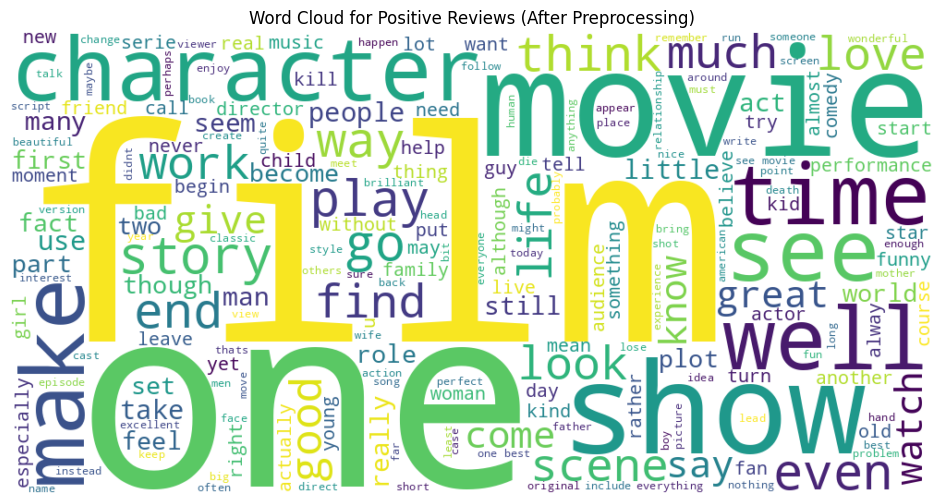

In [ ]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Positive Reviews (After Preprocessing)")
plt.show()

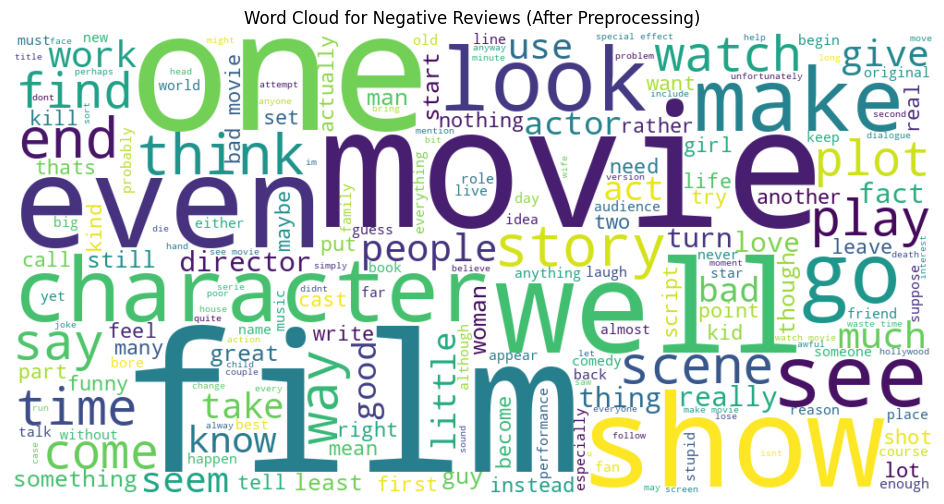

In [ ]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Negative Reviews (After Preprocessing)")
plt.show()

Після попередньої обробки тексту хмари слів стали більш інформативними завдяки видаленню HTML-тегів, стоп-слів та лематизації. Проте найбільш частими залишаються слова, пов'язані з тематикою фільмів (movie, film, character), оскільки вони характерні для обох класів відгуків. Це свідчить про те, що проста частота слів не завжди дозволяє ефективно розрізняти позитивні та негативні відгуки, тому для побудови моделі доцільно використовувати TF-IDF-векторизацію, яка враховує інформативність кожного слова.